# 4.0 - Modelling: Walk-Forward Validation and the Two Finalists

**Question this notebook answers:** how was a final model chosen without ever touching
the test set, and why does the validation scheme matter as much as the model itself?

This notebook **loads the already-serialized final models** (`models/xgb_final.joblib`,
`models/logistic_baseline.joblib`) and scores them on data already produced by
`run_all.py`. It does not retrain, retune, or reselect anything - the walk-forward
hyperparameter search (`notebooks/10_walkforward_tuning.ipynb`, ~90 model fits) and the
bootstrap validation (`07`, `11`) take hours and are summarized from `docs/FACTS.md`, not
reproduced here.

In [1]:
import sys, json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score

sys.path.insert(0, str(Path('..').resolve()))
from src.data import load_split, FEATURE_SET, CATEGORICAL_COLS
from src.features import build_features, prepare_X

train = load_split('train')
test = load_split('test')
print(f"train: {train['issue_d'].min().date()} to {train['issue_d'].max().date()} (N={len(train)})")
print(f"test:  {test['issue_d'].min().date()} to {test['issue_d'].max().date()} (N={len(test)})")


train: 2007-06-01 to 2013-12-01 (N=172988)
test:  2015-01-01 to 2015-12-01 (N=282787)


## The split is temporal - never random

Train ends in Dec/2013, validation is all of 2014, test is all of 2015. A random
train/test split would scatter 2015 loans throughout training - the model would learn
from information that, in reality, did not exist yet at decision time. Every threshold,
hyperparameter, and model choice in this project was made on the **validation** year
(2014) alone; the **test** year (2015) is touched exactly once, in `notebooks/12` and
again here for scoring only (never for choosing anything).

## Walk-forward tuning: choosing hyperparameters across time, not just on one year

`notebooks/10_walkforward_tuning.ipynb` re-scored the same 30 sampled XGBoost
configurations across three expanding windows (train ≤2011 → validate 2012; train ≤2012
→ validate 2013; train ≤2013 → validate 2014) instead of just the single 2014 validation
year used earlier (`notebook 09`). The finding (from `docs/FACTS.md`, not reproduced by
re-running the 90 fits here): the best hyperparameters were **not stable across windows**
- max_depth of the best configuration per window increased monotonically with training-set
size (3 → 4 → 8) - direct evidence that a single validation year can produce an
overconfident hyperparameter choice. The configuration that won on *mean* profit across
all three windows is the one shipped as the final model, not the one that happened to win
on 2014 alone.

## The frozen final configuration

Loaded directly from `models/model_meta.json` - not retyped:

In [2]:
with open(Path('..') / 'models' / 'model_meta.json') as f:
    meta = json.load(f)

frozen_params = {k: meta['hiperparametros'][k] for k in
                  ['max_depth', 'learning_rate', 'n_estimators', 'min_child_weight',
                   'subsample', 'colsample_bytree', 'random_state', 'n_jobs']}
print('XGB_walkforward frozen hyperparameters:')
for k, v in frozen_params.items():
    print(f'  {k}: {v}')
print(f"\nOperating threshold: {meta['threshold_operacional']}")
print(f"FEATURE_SET size: {meta['FEATURE_SET_n']}")
print(f"Trained on train.parquet (SHA256 {meta['train_parquet_sha256'][:16]}...), N={meta['train_n_rows']}")


XGB_walkforward frozen hyperparameters:
  max_depth: 8
  learning_rate: 0.03
  n_estimators: 600
  min_child_weight: 10
  subsample: 0.8
  colsample_bytree: 0.6
  random_state: 42
  n_jobs: 1

Operating threshold: 0.31
FEATURE_SET size: 79
Trained on train.parquet (SHA256 0f7e711edc7c2083...), N=172988


## Scoring the two finalists on the test set

`models/logistic_baseline.joblib` (M1, `LogisticRegression`) and
`models/xgb_final.joblib` (XGB_walkforward) are loaded and scored below - this is
inference on an already-fitted model, not training.

In [3]:
X_train = prepare_X(build_features(train), FEATURE_SET, CATEGORICAL_COLS)
test_feat = build_features(test)
X_test = prepare_X(test_feat, FEATURE_SET, CATEGORICAL_COLS).reindex(columns=X_train.columns, fill_value=0)
y_test = test_feat['target'].values

xgb_final = joblib.load(Path('..') / 'models' / 'xgb_final.joblib')
m1_final = joblib.load(Path('..') / 'models' / 'logistic_baseline.joblib')

y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]
y_prob_m1 = m1_final.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
auc_m1 = roc_auc_score(y_test, y_prob_m1)
print(f'AUC-ROC  XGB_walkforward: {auc_xgb:.4f}  (docs/FACTS.md: 0.6846)')
print(f'AUC-ROC  M1 (LogReg):     {auc_m1:.4f}  (docs/FACTS.md: 0.6847)')


AUC-ROC  XGB_walkforward: 0.6846  (docs/FACTS.md: 0.6846)
AUC-ROC  M1 (LogReg):     0.6847  (docs/FACTS.md: 0.6847)


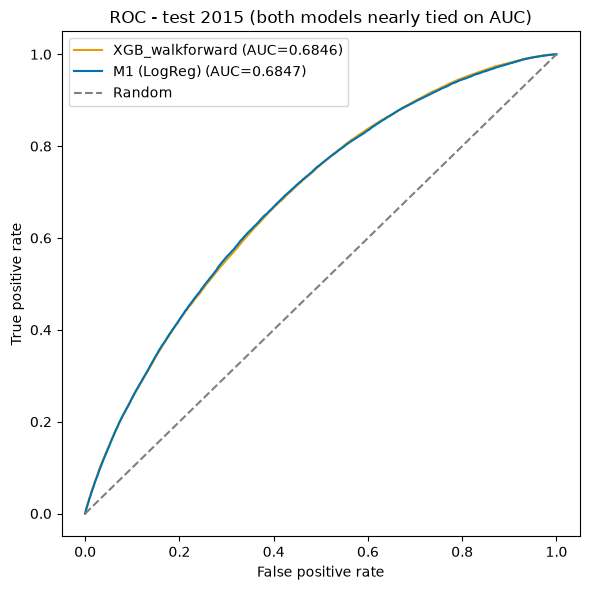

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, y_prob, color in [('XGB_walkforward', y_prob_xgb, '#E69F00'), ('M1 (LogReg)', y_prob_m1, '#0072B2')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC - test 2015 (both models nearly tied on AUC)')
ax.legend()
plt.tight_layout()
plt.show()


The two curves sit almost on top of each other - AUC alone would suggest these are
the same model. They are not: `6.0-evaluation.ipynb` shows they diverge sharply once
profit, not AUC, is the metric. That divergence is the central finding of this project's
evaluation phase, and AUC being nearly identical here is exactly what makes it
noteworthy rather than a coincidence.

## Takeaway

The final model was chosen by re-scoring the same hyperparameter candidates across three
temporal windows, not one - because a single validation year let hyperparameters win by
overfitting to that year's idiosyncrasies. The two finalists that emerge, an XGBoost model
and a logistic regression baseline, score almost identically on AUC on the untouched 2015
test set. That near-tie is the setup for `6.0`, not the conclusion.

**Next:** `5.0-calibration.ipynb` - whether these predicted probabilities can be trusted
at face value, and what happened when the worse-calibrated model was recalibrated.